In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

import pandas as pd
import numpy as np

In [3]:
diabetes_df = pd.read_csv("diabetes.csv")
diabetes_df.head()

,pregnancies,glucose,triceps,insulin,bmi,age,diabetes
0,6,148,35,0,33.6,50,1
1,1,85,29,0,26.6,31,0
2,8,183,0,0,23.3,32,1
3,1,89,23,94,28.1,21,0
4,0,137,35,168,43.1,33,1


In [5]:
X = diabetes_df.drop("glucose", axis=1).values
y = diabetes_df["glucose"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [8]:
# Instance the model
reg = LinearRegression()
reg.fit(X_train, y_train)

y_predictions = reg.predict(X_test)

reg.score(X_test, y_test)

0.30512124844584154

In [9]:
from sklearn.metrics import root_mean_squared_error

root_mean_squared_error(y_test, y_predictions)

25.928394773483223

In [ ]:
# Ridge Regression
from sklearn.linear_model import Ridge

scores = []

# Poderia ser escolhido o RidgeCV que já faz esse trabalho 
# de passar por diferentes alphas e ver qual é o melhor para o modelo
for alpha in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    y_pred = ridge.predict(X_test)
    scores.append(ridge.score(X_test, y_test))

# Escolher o maior score para escolher o melhor alpha
print(scores)

# Escolha o alpha que maximiza o R² (ou minimiza o erro), 
# não necessariamente o menor alpha. Neste caso, alpha ≈ 1.0 
# é o melhor, mas a melhora sobre a regressão linear simples 
# é irrelevante. O Ridge não está agregando valor aqui.

[0.30512138752905715, 0.3051226378292209, 0.30513499768177466, 0.30524455674023443, 0.3051749989347555, 0.2761270934671457]


In [7]:
# Lasso Regression: usa penalidade L1.
# Pode zerar coeficientes, ajudando a selecionar as variaveis mais importantes.
from sklearn.linear_model import Lasso

scores = []
for alpha in [0.01, 1.0, 10.0, 20.0, 50.0]:
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train, y_train)
    lasso_pred = lasso.predict(X_test)
    scores.append(lasso.score(X_test, y_test))
print(scores)

# Melhor alpha = 0.01 pois resultou no maior score (0.30512). Resultado similar a regressao linear simples.
# Lasso nao trouxe melhorias significativas neste dataset.


[0.30512461944945246, 0.3007039267182937, 0.1876696175260042, 0.18783512173080763, 0.15710253040109312]


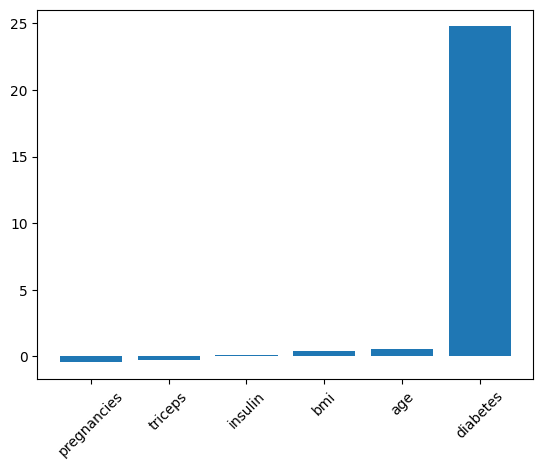

In [8]:
# Importa o matplotlib para criação de gráficos
import matplotlib.pyplot as plt

# Extrai os nomes das variáveis preditoras (removendo a variável alvo 'glucose')
names = diabetes_df.drop("glucose", axis=1).columns

# Instancia o modelo Lasso com alpha=0.01 (melhor valor encontrado no bloco anterior)
lasso = Lasso(alpha=0.01)

# Treina o modelo e extrai os coeficientes de cada variável
# O Lasso tende a zerar coeficientes de variáveis menos importantes
lasso_coef = lasso.fit(X, y).coef_

# Cria um gráfico de barras para visualizar a magnitude dos coeficientes de cada variável
plt.bar(names, lasso_coef)

# Rotaciona os nomes das variáveis no eixo X para facilitar a leitura
plt.xticks(rotation=45)

# Exibe o gráfico
plt.show()
